Predict the price of the Uber ride from a given pickup point to the agreed drop-off location. Perform
following tasks:
1. Pre-process the dataset.
2. Identify outliers.
3. Check the correlation.
4. Implement random forest model.
5. Evaluate the model using R2, RMSE, etc.

Use Uber Dataset:
[Uber.csv](https://www.kaggle.com/datasets/yasserh/uber-fares-dataset)

In [1]:
# pip install numpy==1.24.3 pandas==2.1.1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as  plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [3]:
data = pd.read_csv('D:/KAUSTUBH/LP3 Final/uber.csv')
print(data.head())

   Unnamed: 0                            key  fare_amount  \
0    24238194    2015-05-07 19:52:06.0000003          7.5   
1    27835199    2009-07-17 20:04:56.0000002          7.7   
2    44984355   2009-08-24 21:45:00.00000061         12.9   
3    25894730    2009-06-26 08:22:21.0000001          5.3   
4    17610152  2014-08-28 17:47:00.000000188         16.0   

           pickup_datetime  pickup_longitude  pickup_latitude  \
0  2015-05-07 19:52:06 UTC        -73.999817        40.738354   
1  2009-07-17 20:04:56 UTC        -73.994355        40.728225   
2  2009-08-24 21:45:00 UTC        -74.005043        40.740770   
3  2009-06-26 08:22:21 UTC        -73.976124        40.790844   
4  2014-08-28 17:47:00 UTC        -73.925023        40.744085   

   dropoff_longitude  dropoff_latitude  passenger_count  
0         -73.999512         40.723217                1  
1         -73.994710         40.750325                1  
2         -73.962565         40.772647                1  
3         

In [4]:
# Drop irrelevant columns
data = data.drop(["Unnamed: 0","key"], axis=1)

# Check for missing values in the dataset
missing_values = data.isnull().sum()

# Drop rows with missing values (as they are minimal)
data = data.dropna()

# Convert pickup_datetime to datetime format and extract useful time features
data['pickup_datetime'] = pd.to_datetime(data['pickup_datetime'], errors='coerce')
data['pickup_day'] = data['pickup_datetime'].dt.day
data['hour'] = data['pickup_datetime'].dt.hour
data['day'] = data['pickup_datetime'].dt.dayofweek

# Verify the preprocessing
data.head(), missing_values

(   fare_amount           pickup_datetime  pickup_longitude  pickup_latitude  \
 0          7.5 2015-05-07 19:52:06+00:00        -73.999817        40.738354   
 1          7.7 2009-07-17 20:04:56+00:00        -73.994355        40.728225   
 2         12.9 2009-08-24 21:45:00+00:00        -74.005043        40.740770   
 3          5.3 2009-06-26 08:22:21+00:00        -73.976124        40.790844   
 4         16.0 2014-08-28 17:47:00+00:00        -73.925023        40.744085   
 
    dropoff_longitude  dropoff_latitude  passenger_count  pickup_day  hour  day  
 0         -73.999512         40.723217                1           7    19    3  
 1         -73.994710         40.750325                1          17    20    4  
 2         -73.962565         40.772647                1          24    21    0  
 3         -73.965316         40.803349                3          26     8    4  
 4         -73.973082         40.761247                5          28    17    3  ,
 fare_amount          0
 

In [5]:
# Calculate distance
data['distance'] = np.sqrt((data['dropoff_longitude'] - data['pickup_longitude'])**2 + 
                           (data['dropoff_latitude'] - data['pickup_latitude'])**2)

### What are outliers? Why we need to remove outlier? Techniques to remove outlier.? What is interquartile range? How to calculate it?
### Techniques to Remove Outliers

1. **Z-Score Method**:
   - **What it is**: The Z-score represents how many standard deviations a data point is from the mean of the dataset.
   - **How it works**: A data point is considered an outlier if its Z-score is greater than a certain threshold (commonly 3 or -3). This means the data point is far away from the average compared to most data points.
   - **Formula**: 
     $$
     Z = \frac{(X - \mu)}{\sigma}
     $$
     Where \(X\) is the data point, \(\mu\) is the mean, and \(\sigma\) is the standard deviation of the data.
   
2. **Interquartile Range (IQR) Method**:
   - **What it is**: IQR measures the statistical range between the first (Q1) and third (Q3) quartiles of a dataset, representing the middle 50% of the data.
   - **How it works**: Outliers are identified as values that fall below \( Q1 - 1.5 \times IQR \) or above \( Q3 + 1.5 \times IQR \). These points are considered unusually far from the central data distribution.
   - **Formula**:
     $$
     \text{Lower bound} = Q1 - 1.5 \times IQR
     $$
     $$
     \text{Upper bound} = Q3 + 1.5 \times IQR
     $$
     Where IQR = $$ Q3 - Q1 $$.

3. **Visual Methods**:
   - **Box Plots**: A box plot visually shows the spread of data, with outliers typically shown as points outside the "whiskers" of the box (which extend to 1.5 times the IQR from Q1 and Q3).
   - **Scatter Plots**: Outliers appear as points far away from the dense clusters of data in scatter plots.

4. **Isolation Forests**:
   - **What it is**: A machine learning-based method that isolates outliers by randomly selecting features and then partitioning the data to isolate individual points. The algorithm is based on the idea that outliers are few and different, and thus easier to isolate.

5. **Percentile-based Method**:
   - **What it is**: In this method, outliers are determined based on extreme values at certain percentiles, like the 1st and 99th percentiles.
   - **How it works**: Any data points outside a specified percentile range (e.g., below the 1st percentile or above the 99th percentile) are considered outliers.

---

### Interquartile Range (IQR)

- **What it is**: The **Interquartile Range (IQR)** is a measure of statistical dispersion that shows the range within which the central 50% of the data lie. It is used to identify outliers and summarize data distribution.
  
- **How to Calculate**:
  - **Q1 (First Quartile)**: The median of the lower half of the data (25th percentile).
  - **Q3 (Third Quartile)**: The median of the upper half of the data (75th percentile).
  - **IQR**: $$ IQR = Q3 - Q1 $$

- **Outlier Detection**:
  - Outliers are defined as data points that fall below \( Q1 - 1.5 \times IQR \) or above \( Q3 + 1.5 \times IQR \).
  - Points outside this range are considered outliers, as they are significantly different from the main cluster of the data.

- **Example**:
  If the IQR of a dataset is 10, the outlier boundaries would be:
  - Lower Bound: $$ Q1 - 1.5 \times 10 $$
  - Upper Bound: $$ Q3 + 1.5 \times 10 $$

The IQR method is especially useful for identifying outliers in skewed distributions, as it is not affected by extreme values in the dataset.

In [7]:
# Filter outliers based on distance and fare
data = data[(data['distance'] < data['distance'].quantile(0.99)) &
            (data['fare_amount'] < data['fare_amount'].quantile(0.99))]

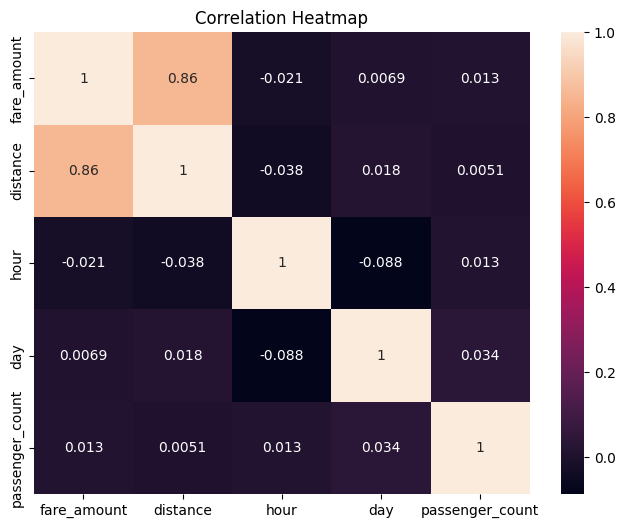

In [8]:
# Check correlation
plt.figure(figsize=(8, 6))
sns.heatmap(data[['fare_amount', 'distance', 'hour', 'day', 'passenger_count']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [9]:
# Prepare data for training
X = data[['distance', 'hour', 'day', 'passenger_count']]
y = data['fare_amount']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# Train Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [11]:
# Evaluate model
y_pred = model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.734234351846624
RMSE: 3.8886530330726283
MAE: 2.2979958923697335


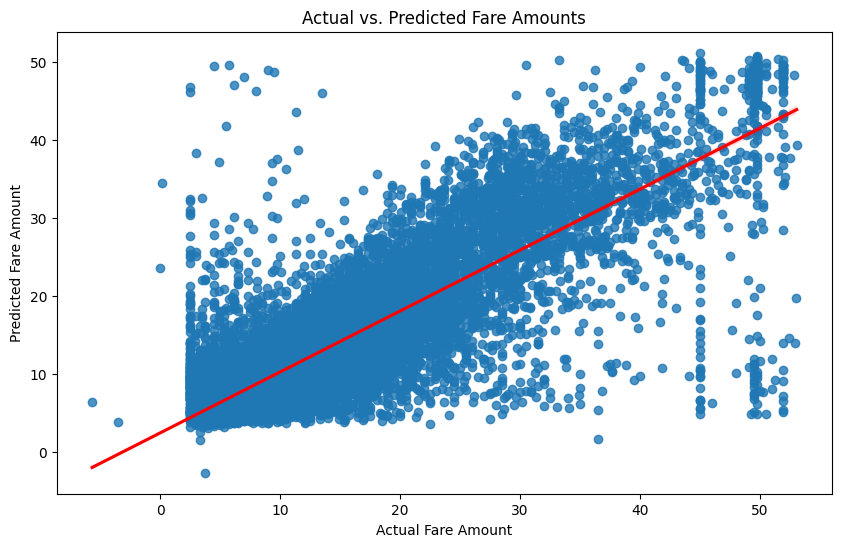

In [12]:
# Plot actual vs. predicted values
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, line_kws={'color': 'red'})
plt.xlabel("Actual Fare Amount")
plt.ylabel("Predicted Fare Amount")
plt.title("Actual vs. Predicted Fare Amounts")
plt.show()

### What is boxplot? What is the use of boxplot?
### Box Plot: 

A **box plot** (also called a **box-and-whisker plot**) is a graphical representation of a dataset's distribution, showing its **central tendency**, **spread**, and **outliers**. It visually summarizes the data using five key statistical measures:

1. **Median** (Q2): The middle value that divides the dataset into two equal halves. It is represented by a line inside the box.
2. **First Quartile (Q1)**: The median of the lower half of the dataset (25th percentile). It marks the left edge of the box.
3. **Third Quartile (Q3)**: The median of the upper half of the dataset (75th percentile). It marks the right edge of the box.
4. **Interquartile Range (IQR)**: The range between Q1 and Q3 (IQR = Q3 - Q1), showing the middle 50% of the data.
5. **Whiskers**: Lines extending from the box to show the range of the data, excluding outliers. Whiskers typically extend to 1.5 times the IQR from Q1 and Q3.
6. **Outliers**: Data points that fall outside the whiskers (typically beyond 1.5 times the IQR). These are marked as individual points outside the whiskers.

### Structure of a Box Plot:
- **Box**: Represents the interquartile range (IQR) between Q1 and Q3.
- **Line in the box**: Represents the **median** (Q2).
- **Whiskers**: Extend to the smallest and largest values within 1.5 × IQR from Q1 and Q3.
- **Outliers**: Data points that lie outside the whiskers are marked individually.

---

### Use of Box Plot:

1. **Visualizing Distribution**:
   - It provides a quick summary of the data distribution, including central tendency (median), spread (IQR), and skewness.

2. **Identifying Outliers**:
   - Outliers are easily visible as individual points outside the whiskers. This makes box plots useful for spotting unusual or extreme values.

3. **Comparing Multiple Distributions**:
   - Box plots are especially useful when comparing multiple datasets or groups. You can easily compare the spread and central tendency of different groups side by side.

4. **Identifying Skewness**:
   - The position of the median relative to Q1 and Q3 can indicate skewness. If the median is closer to Q1, the data is skewed to the right (positive skew); if closer to Q3, it's skewed to the left (negative skew).

5. **Detecting Data Spread**:
   - The length of the box and whiskers shows how spread out the data is. A wider box indicates more variability, while a narrower box indicates less variability.

### Example:
In a dataset of exam scores, a box plot might show that most students scored between 50 and 80 (IQR), the median score was 65, and there were a few students with very high scores (outliers) above 95.